**AirBnb NYC Dataset**

The AirBnb NYC dataset contains the information about AirBnb's listing in New York City. It provides details about properties, hosts, pricing, availability, locations and customer reviews.
The dataset contains 48,895 rows and 16 columns.

In [24]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Loading and Inspecting the Dataset

df = pd.read_csv("AirBnb NYC data.csv")
print("First 5 rows")
display(df.head())

print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])

print("Data Types:")
print(df.dtypes)

print("\nSummary Statistics:")
display(df.describe(include='all'))

First 5 rows


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


Rows:  48895
Columns:  16
Data Types:
id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group                   str
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
dtype: object

Summary Statistics:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [11]:
# Dataset Cleaning

print("Missing Values Before Cleaning:")
print(df.isnull().sum())

# Convert last_review to datetime
df['last_review'] = pd.to_datetime(df['last_review'])

# Fill missing values
df['reviews_per_month'] = df['reviews_per_month'].fillna(
    df['reviews_per_month'].median()
)

df['last_review'] = df['last_review'].fillna(
    pd.Timestamp("1900-01-01")
)

# (Optional) Fill missing name and host_name
df['name'] = df['name'].fillna("Unknown")
df['host_name'] = df['host_name'].fillna("Unknown")

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

print("\nDataset Shape After Removing Duplicates:")
print(df.shape)

Missing Values Before Cleaning:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing Values After Cleaning:
id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                      

In [13]:
# Descriptive Statistics

numeric_cols = df.select_dtypes(include=np.number)

statistics = pd.DataFrame({
    "Mean" : numeric_cols.mean(),
    "Median" : numeric_cols.median(),
    "Mode" : numeric_cols.mode().iloc[0],
    "Standard Deviation" : numeric_cols.std(),
    "Minimum" : numeric_cols.min(),
    "Maximum" : numeric_cols.max()
})

display(statistics)

,Mean,Median,Mode,Standard Deviation,Minimum,Maximum
id,1.901714e+07,1.967728e+07,2.539000e+03,1.098311e+07,2539.00000,3.648724e+07
host_id,6.762001e+07,3.079382e+07,2.195179e+08,7.861097e+07,2438.00000,2.743213e+08
latitude,4.072895e+01,4.072307e+01,4.071813e+01,5.453008e-02,40.49979,4.091306e+01
longitude,-7.395217e+01,-7.395568e+01,-7.395677e+01,4.615674e-02,-74.24442,-7.371299e+01
price,1.527207e+02,1.060000e+02,1.000000e+02,2.401542e+02,0.00000,1.000000e+04
minimum_nights,7.029962e+00,3.000000e+00,1.000000e+00,2.051055e+01,1.00000,1.250000e+03
number_of_reviews,2.327447e+01,5.000000e+00,0.000000e+00,4.455058e+01,0.00000,6.290000e+02
reviews_per_month,1.238930e+00,7.200000e-01,7.200000e-01,1.520861e+00,0.01000,5.850000e+01
calculated_host_listings_count,7.143982e+00,1.000000e+00,1.000000e+00,3.295252e+01,1.00000,3.270000e+02
availability_365,1.127813e+02,4.500000e+01,0.000000e+00,1.316223e+02,0.00000,3.650000e+02


**Histogram**

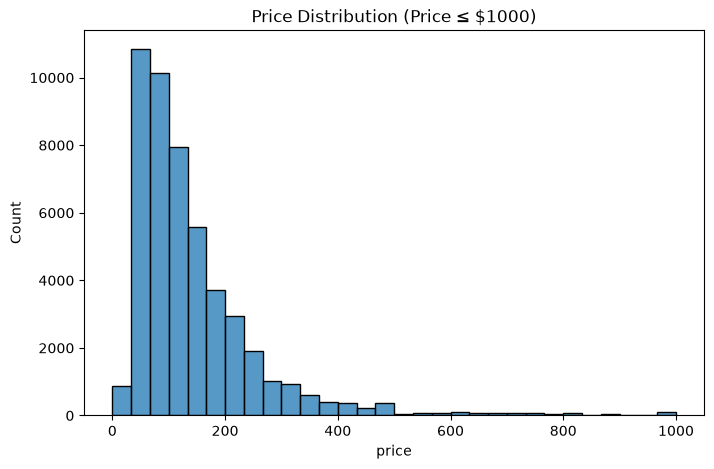

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['price'] <= 1000]['price'], bins=30)
plt.title("Price Distribution (Price ≤ $1000)")
plt.show()

The historam shows that the most AirBnb listings are priced between $50 and $200 per night, which shows that the affordable prices are available. As the price increases, the number of listings decreases. Which means that the budget and mid-range stays are more common, while expensive and luxury properties are available but are much fewer in number.

**Box Plot**

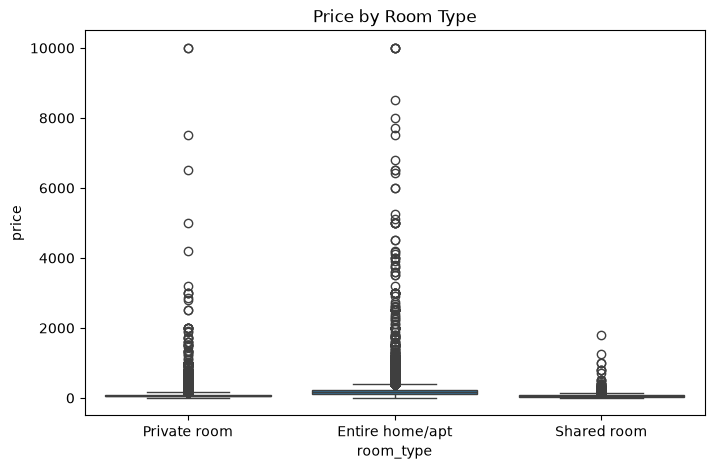

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title("Price by Room Type")
plt.show()

The Box Plot shows that :
- Private rooms have moderate prices.
- Entire apartments have the highest median price.
- Shared rooms are the least expensive.
- Entire apartments show the highest price variation.
- All room types contain many high-priced outliers, especially entire apartments.

People looking for Budget friendly stays are usually choosing shared rooms or private rooms, while who wants more privacy and comfort they prefers entire apartments, even though they are more expensive. The presence of many high-priced outliers shows that there are also luxury properties available on Airbnb.

**Scatter Plot**

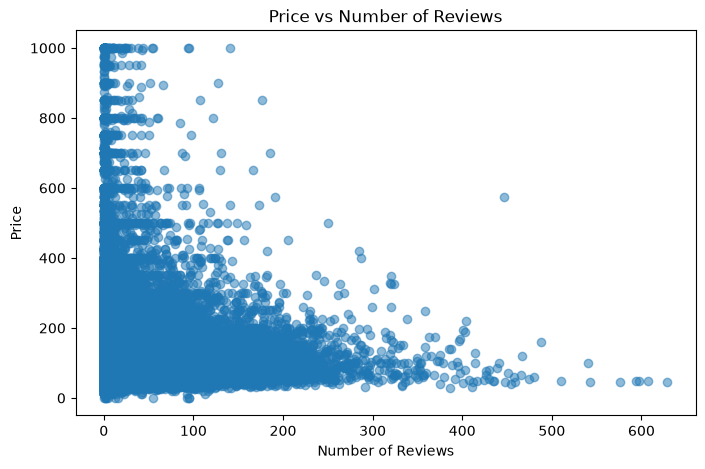

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(
    df[df['price'] <= 1000]['number_of_reviews'],
    df[df['price'] <= 1000]['price'],
    alpha=0.5
)

plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.show()

THis Scatter plot shows that there is a weak negative relationship between price and number of reviews. Most listings with many reviews are priced at lower or moderate rates, while expensive listings usually have fewer reviews. This shows that affordable Airbnb listings are booked and reviewed more often, where high priced listings attracts fewer guests and receive fewer reviews.

**Bar Chart**

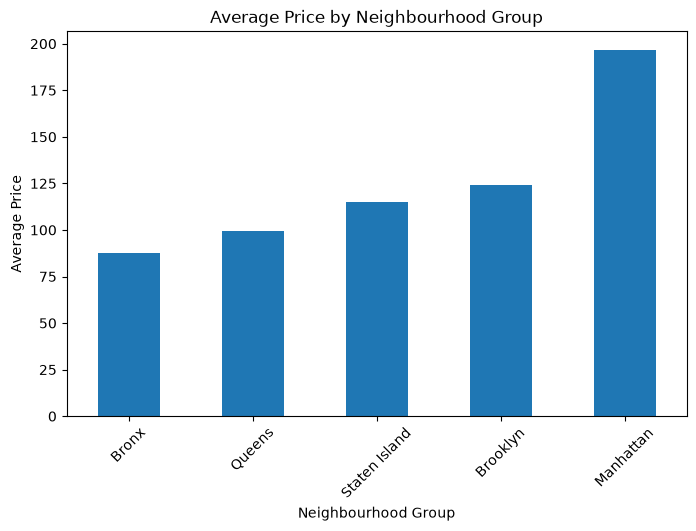

In [23]:
avg_price = df.groupby('neighbourhood_group')['price'].mean().sort_values()

plt.figure(figsize=(8,5))
avg_price.plot(kind='bar')

plt.title("Average Price by Neighbourhood Group")
plt.xlabel("Neighbourhood Group")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.show()

This Bar chart shows that Manhattan has the highest average AirBnb price around $197, which is the most expensive neighbourhood group. Brooklyn has the second highest average price. The Bronox has the lowest average price which is arounf $88, making it the most affordable area. This indicates that Airbnb prices vary across neighbourhoods, the central and popular locations generally charging higher prices.

**Correlation Heatmap**

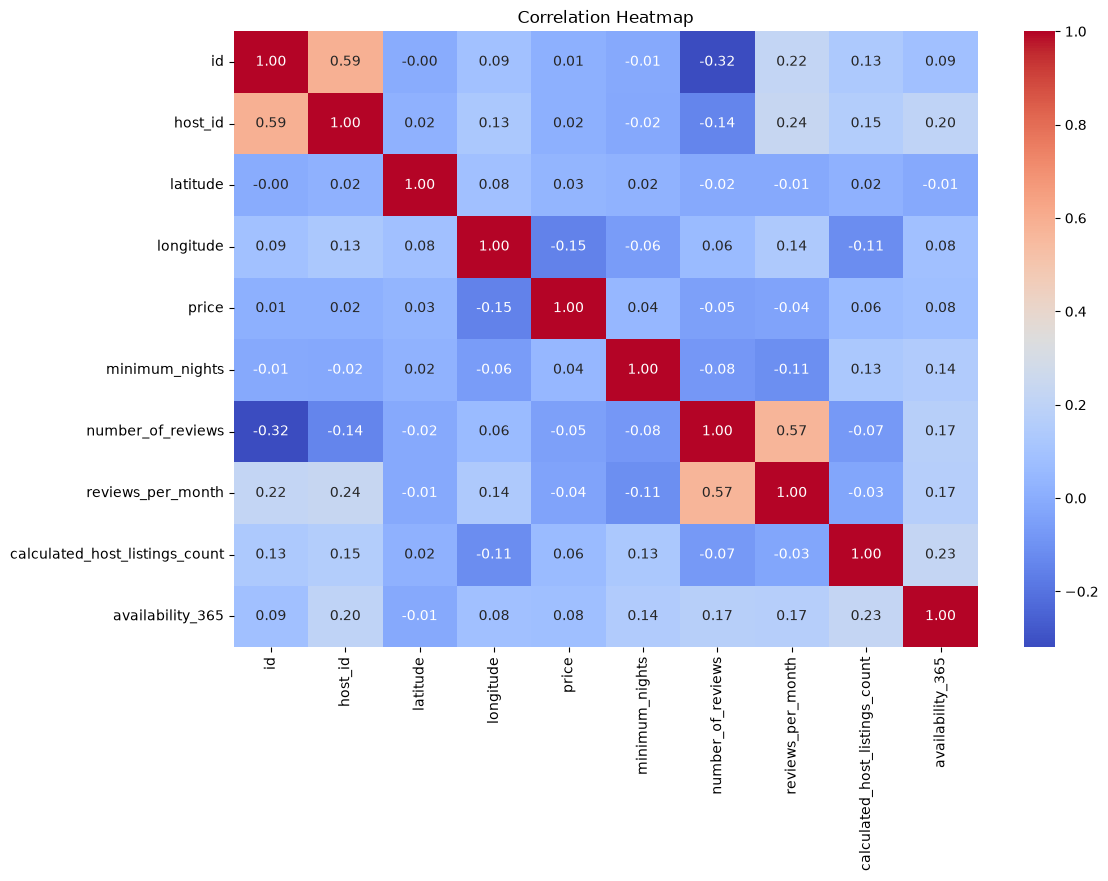

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that most variables have weak correlations, meaning they do not strongly affect each other. The strongest positive correlation is between number of reviews and reviews per month is 0.57, indicating that listings with more reviews usually receive reviews more frequently. Price has a very weak correlation with other variables (between -0.15 and 0.08), which shows that price is influenced by factors not included in this heatmap, such as location, room type, and amenities. Overall, there are no strong positive or negative correlations among most numerical features.

In [19]:
# Outliers

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df['price'] < Q1 - 1.5*IQR) | (df['price'] > Q3 + 1.5*IQR)]

print("Number of Outliers:", len(outliers))
display(outliers.head())

Number of Outliers: 2972


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
61,15396,Sunny & Spacious Chelsea Apartment,60278,Petra,Manhattan,Chelsea,40.74623,-73.99530,Entire home/apt,375,180,5,2018-11-03,0.12,1,180
85,19601,perfect for a family or small group,74303,Maggie,Brooklyn,Brooklyn Heights,40.69723,-73.99268,Entire home/apt,800,1,25,2016-08-04,0.24,1,7
103,23686,2000 SF 3br 2bath West Village private townhouse,93790,Ann,Manhattan,West Village,40.73096,-74.00319,Entire home/apt,500,4,46,2019-05-18,0.55,2,243
114,26933,2 BR / 2 Bath Duplex Apt with patio! East Village,72062,Bruce,Manhattan,East Village,40.72540,-73.98157,Entire home/apt,350,2,7,2017-08-09,0.06,4,298
121,27659,3 Story Town House in Park Slope,119588,Vero,Brooklyn,South Slope,40.66499,-73.97925,Entire home/apt,400,2,16,2018-12-30,0.24,2,216


**Conclusion**

The EDA of the Airbnb NYC dataset shows that location and room type are the main factors influencing Airbnb prices. Most listings are affordable, while premium-priced properties are relatively few. Manhattan is the most expensive neighbourhood group, whereas the Bronx offers the most budget-friendly options. Additionally, lower-priced listings generally attract more customer reviews, suggesting higher demand. The analysis also identified 2,972 price outliers, representing premium and luxury properties that can influence the overall price distribution. Overall, this EDA highlights how location, room type, and pricing affect Airbnb listings and provides useful insights that can help hosts optimize pricing strategies and travelers choose accommodations based on their budget and preferences.